In [1]:
import math
import random
from collections.abc import Callable

import matplotlib.pyplot as plt

from jacinta.processor.evaluator import ZScoreEvaluator
from jacinta.processor.receiver import Receiver, ReceiverSample
from jacinta.processor.transmitter import Transmitter
from jacinta.utils.scheduler import ConstantScheduler

In [2]:
MIN_X, MAX_X = -10.0, 10.0
MIN_Y, MAX_Y = -10.0, 10.0

# hyperparameters
HITS_RATE = 1000
MIN_WIDTH = 0.001
MAX_DEPTH = None
SEED = 42

# simulation parameters
N_STEPS = 40000
N_PLOTS = 5

In [3]:
def eval_sampling_function(
    sampling_function: Callable[[float, float], float], x: float, y: float
) -> float:
    """
    Safely evaluate a sampling function for the given values.

    Args:
        sampling_function (Callable[[float, float], float]): The sampling function
            to evaluate.
        x (float): The first value to evaluate the sampling function at.
        y (float): The second value to evaluate the sampling function at.

    Returns:
        float: The result of the sampling function evaluation.
    """
    try:
        p = sampling_function(x, y)
        if not math.isfinite(p):
            p = math.nan
        p = max(p, 0.0)
    except (ArithmeticError, ValueError):
        p = math.nan
    return p

In [4]:
def plot_sampling_function(
    ax: plt.Axes,
    sampling_function: Callable[[float, float], float],
    n_points: int = 100,
    elev: float = 30.0,
    azim: float = 30.0,
) -> None:
    """
    Plot a sampling function.

    Args:
        ax (plt.Axes): The axes to plot on.
        sampling_function (Callable[[float, float], float]): The sampling function
            to plot.
        n_points (int): The number of points to plot per dimension.
            Defaults to 100.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
    """
    # evaluate the sampling function
    x_step = (MAX_X - MIN_X) / (n_points - 1)
    y_step = (MAX_Y - MIN_Y) / (n_points - 1)
    x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
    y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
    x_grid = [x_val for y_val in y_vals for x_val in x_vals]
    y_grid = [y_val for y_val in y_vals for x_val in x_vals]
    p_grid = [
        eval_sampling_function(sampling_function, x_val, y_val)
        for y_val in y_vals
        for x_val in x_vals
    ]
    # build the mesh triangles
    triangles = []
    for row in range(n_points - 1):
        for col in range(n_points - 1):
            # build the mesh cell
            top_left = row * n_points + col
            top_right = top_left + 1
            bottom_left = (row + 1) * n_points + col
            bottom_right = bottom_left + 1
            # split the cell into two triangles
            triangles.append([top_left, top_right, bottom_right])
            triangles.append([top_left, bottom_right, bottom_left])
    # plot the sampling function
    ax.plot_trisurf(
        x_grid,
        y_grid,
        p_grid,
        triangles=triangles,
        cmap="summer",
        antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("p", rotation=90)
    ax.set_title(f"Sampling Function (elev={elev}, azim={azim})")
    ax.grid(visible=True)
    return

In [5]:
def get_leaves(receiver: Receiver) -> list[Receiver]:
    """
    Get the receiver leaves.

    Args:
        receiver (Receiver): The receiver to get the leaves of.

    Returns:
        list[Receiver]: A list containing the receiver leaves.
    """
    # check if the receiver is a leaf
    if receiver.is_leaf:
        leaves = [receiver]
    # otherwise, recursively get its leaves
    else:
        leaves = []
        for child in receiver.children:
            child_leaves = get_leaves(child)
            leaves.extend(child_leaves)
    return leaves

In [6]:
def plot_receiver(ax: plt.Axes, receiver: Receiver) -> None:
    """
    Plot the spatial specialization of a receiver.

    Args:
        ax (plt.Axes): The axes to plot on.
        receiver (Receiver): The receiver to plot.
    """
    # get the receiver leaves
    leaves = get_leaves(receiver)
    # sort the leaves by their lower bounds
    leaves.sort(key=lambda leaf: (leaf.bounds[0][0], leaf.bounds[1][0]))
    # plot each receiver leaf
    for leaf in leaves:
        x_lower, x_upper = leaf.bounds[0]
        y_lower, y_upper = leaf.bounds[1]
        ax.fill(
            [x_lower, x_upper, x_upper, x_lower],
            [y_lower, y_lower, y_upper, y_upper],
            color="C0",
            alpha=0.3,
        )
        ax.vlines([x_lower, x_upper], ymin=y_lower, ymax=y_upper)
        ax.hlines([y_lower, y_upper], xmin=x_lower, xmax=x_upper)
    # plot the receiver
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Receiver Spatial Specialization")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(visible=True, alpha=0.3)
    return

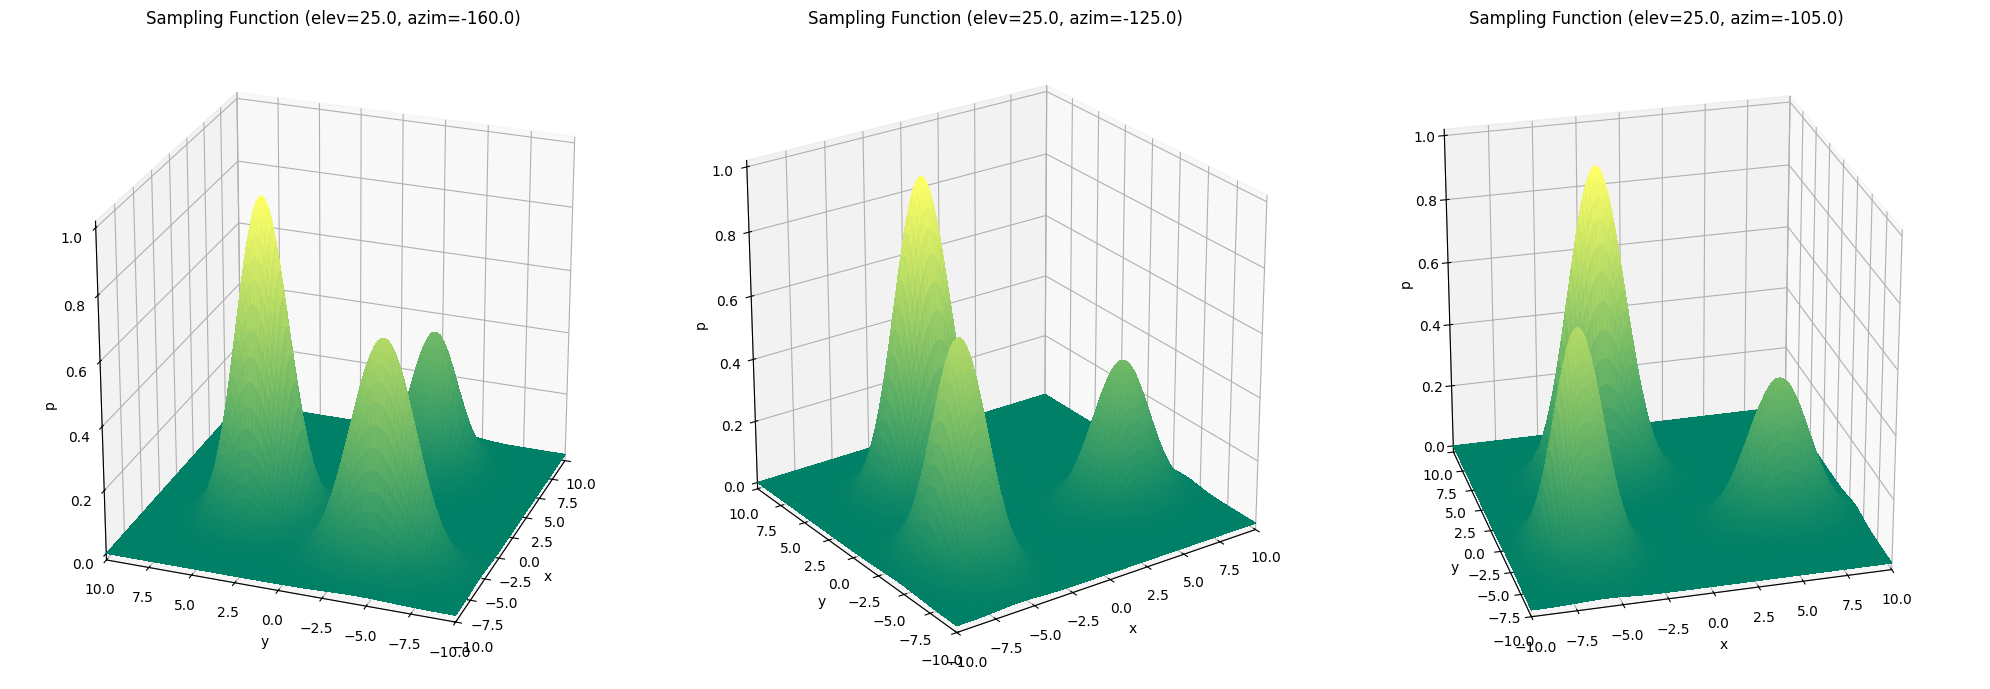

In [7]:
def sampling_function(x: float, y: float) -> float:
    """
    Sampling function.

    Args:
        x (float): The first value to evaluate the sampling function at.
        y (float): The second value to evaluate the sampling function at.

    Returns:
        float: The relative probability of sampling the point.
    """
    p = (
        1.00 * math.exp(-0.5 * (((x + 3.0) / 1.6) ** 2 + ((y - 3.5) / 1.4) ** 2))
        + 0.70 * math.exp(-0.5 * (((x + 6.0) / 1.3) ** 2 + ((y + 4.5) / 1.8) ** 2))
        + 0.45 * math.exp(-0.5 * (((x - 5.5) / 1.7) ** 2 + ((y + 3.5) / 1.3) ** 2))
    )
    return p


# plot the sampling function
fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
plot_sampling_function(ax[0], sampling_function, elev=25.0, azim=-160.0)
plot_sampling_function(ax[1], sampling_function, elev=25.0, azim=-125.0)
plot_sampling_function(ax[2], sampling_function, elev=25.0, azim=-105.0)
# adjust the aspect ratio of each plot
for axis in ax:
    axis.set_box_aspect((1, 1, 1), zoom=0.95)
fig.tight_layout()
plt.show()

In [8]:
def get_sampling_function_max(
    sampling_function: Callable[[float, float], float],
    n_points: int = 100,
) -> float:
    """
    Approximate the maximum of a sampling function.

    Args:
        sampling_function (Callable[[float, float], float]): The sampling function
            to evaluate.
        n_points (int): The number of points to evaluate per dimension.
            Defaults to 100.

    Returns:
        float: The approximate maximum of the sampling function.
    """
    # evaluate the sampling function
    x_step = (MAX_X - MIN_X) / (n_points - 1)
    y_step = (MAX_Y - MIN_Y) / (n_points - 1)
    x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
    y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
    p_vals = [
        eval_sampling_function(sampling_function, x_val, y_val)
        for y_val in y_vals
        for x_val in x_vals
    ]
    # get the sampling function maximum
    max_p = max(p_vals)
    return max_p

In [9]:
def sample(
    sampling_function: Callable[[float, float], float],
    max_p: float,
    rng: random.Random,
) -> ReceiverSample:
    """
    Sample from a sampling function.

    Args:
        sampling_function (Callable[[float, float], float]): The sampling function.
        max_p (float): The upper bound used for rejection sampling.
        rng (random.Random): The random number generator used for sampling.

    Returns:
        ReceiverSample: The sampled input.
    """
    # sample using rejection sampling
    while True:
        x = rng.uniform(MIN_X, MAX_X)
        y = rng.uniform(MIN_Y, MAX_Y)
        p = rng.uniform(0.0, max_p)
        if p <= eval_sampling_function(sampling_function, x, y):
            break
    # generate the receiver sample
    rsample = ReceiverSample(
        coordinates=(x, y),
    )
    return rsample

In [10]:
# initialize a 1D Transmitter
transmitter = Transmitter(
    bounds=((-10.0, 10.0),),
    evaluator=ZScoreEvaluator(0.001, 0.001),
    bias_scale_scheduler=ConstantScheduler(value=10.0),
    learning_rate_scheduler=ConstantScheduler(value=0.001),
    hits_rate_scheduler=ConstantScheduler(value=1000),
    min_width=1,
    max_depth=0,
    seed=42,
)

In [11]:
# initialize a 2D Receiver
receiver = Receiver(
    bounds=((MIN_X, MAX_X), (MIN_Y, MAX_Y)),
    transmitter=transmitter,
    hits_rate_scheduler=ConstantScheduler(value=HITS_RATE),
    min_width=MIN_WIDTH,
    max_depth=MAX_DEPTH,
)

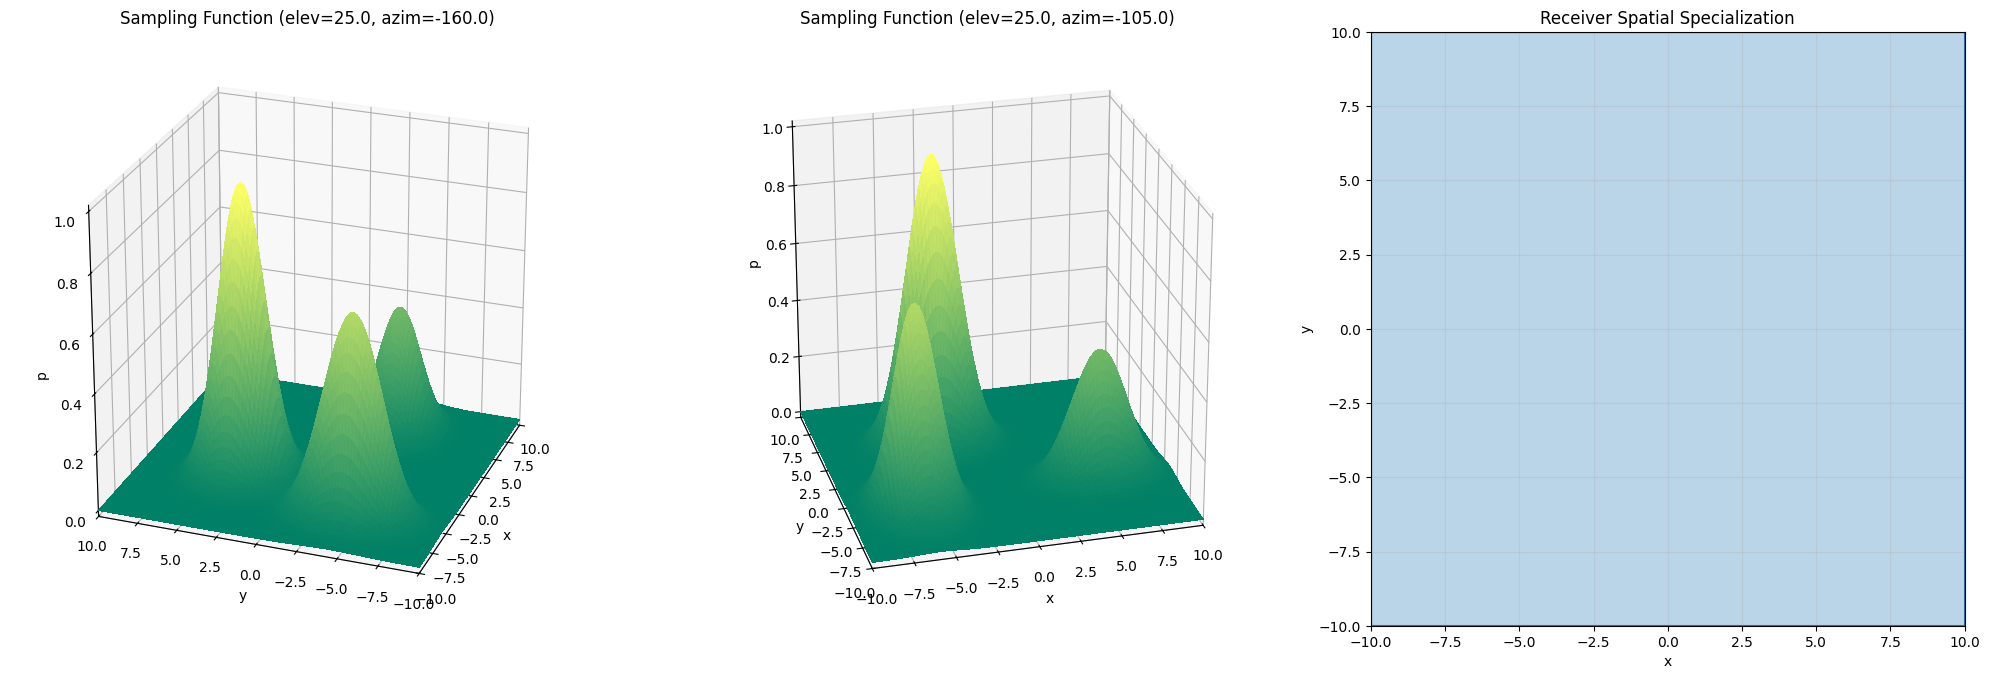

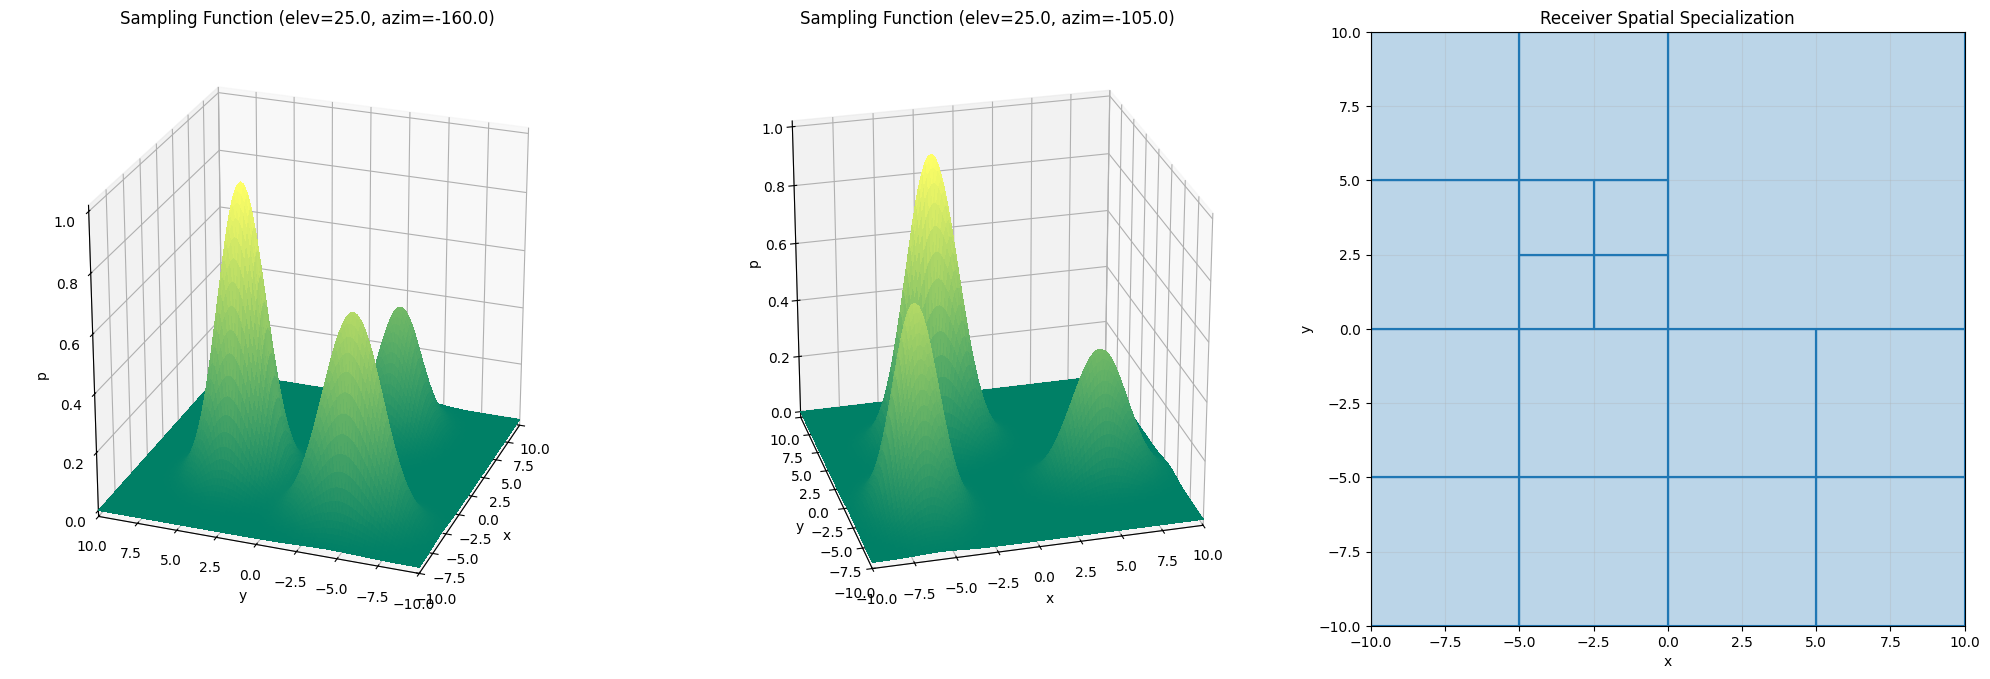

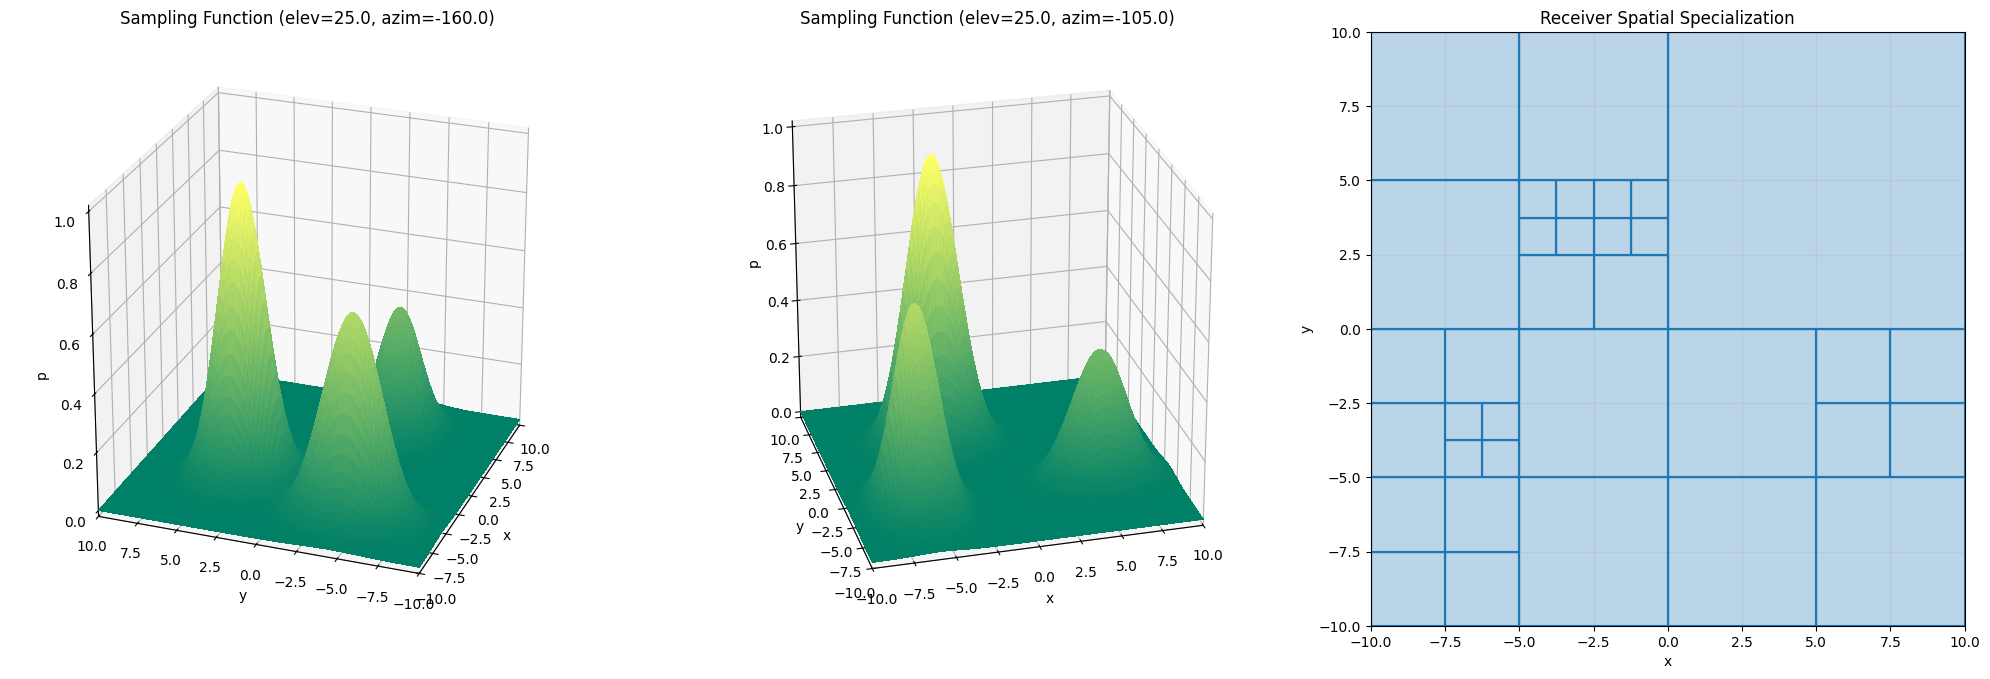

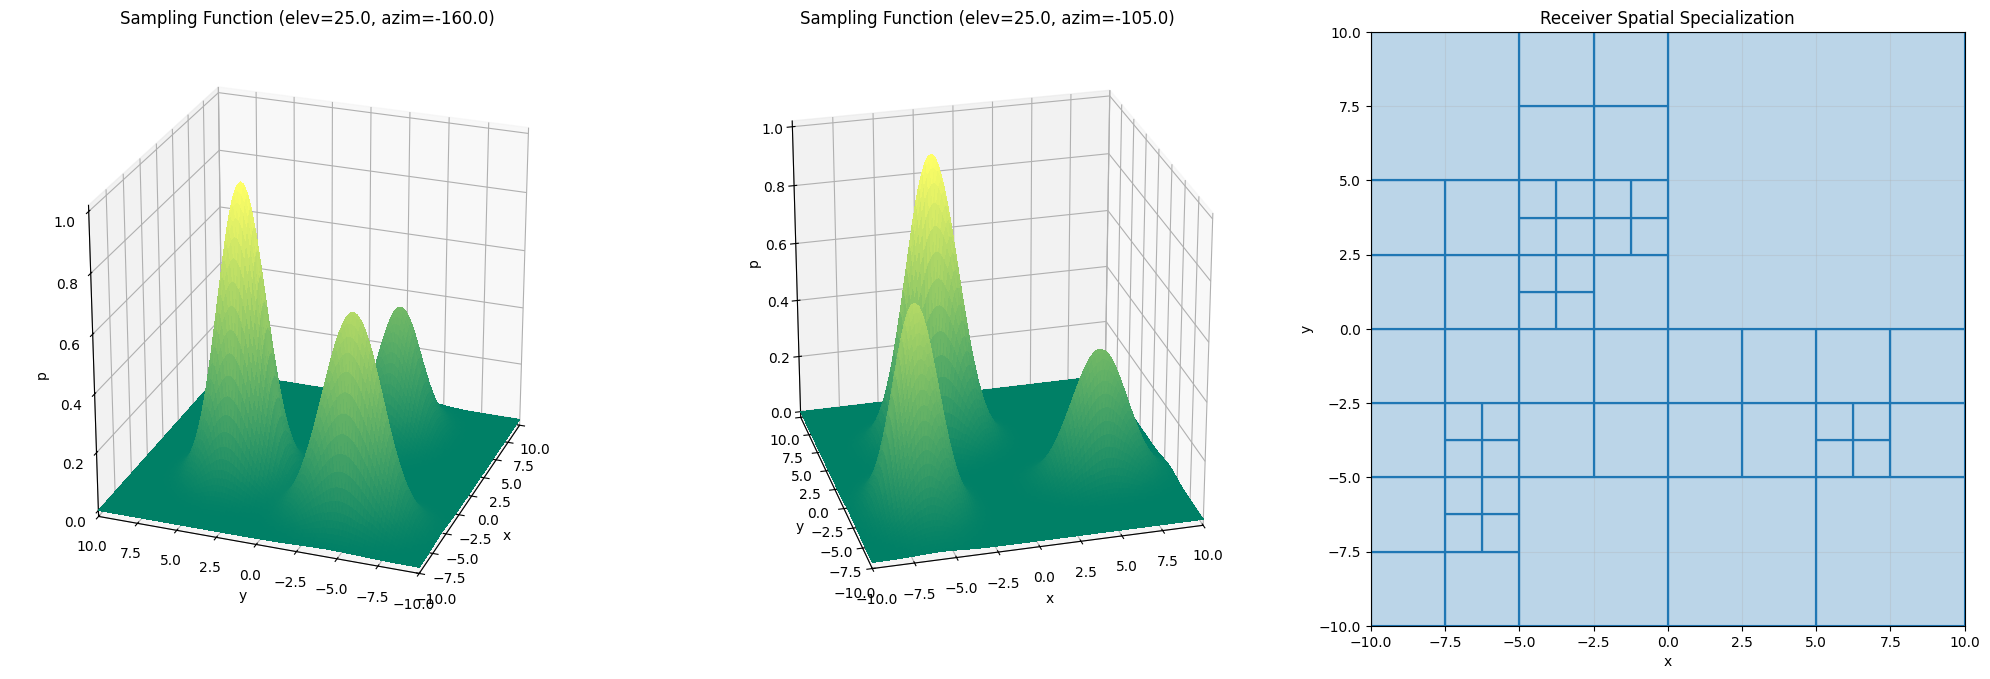

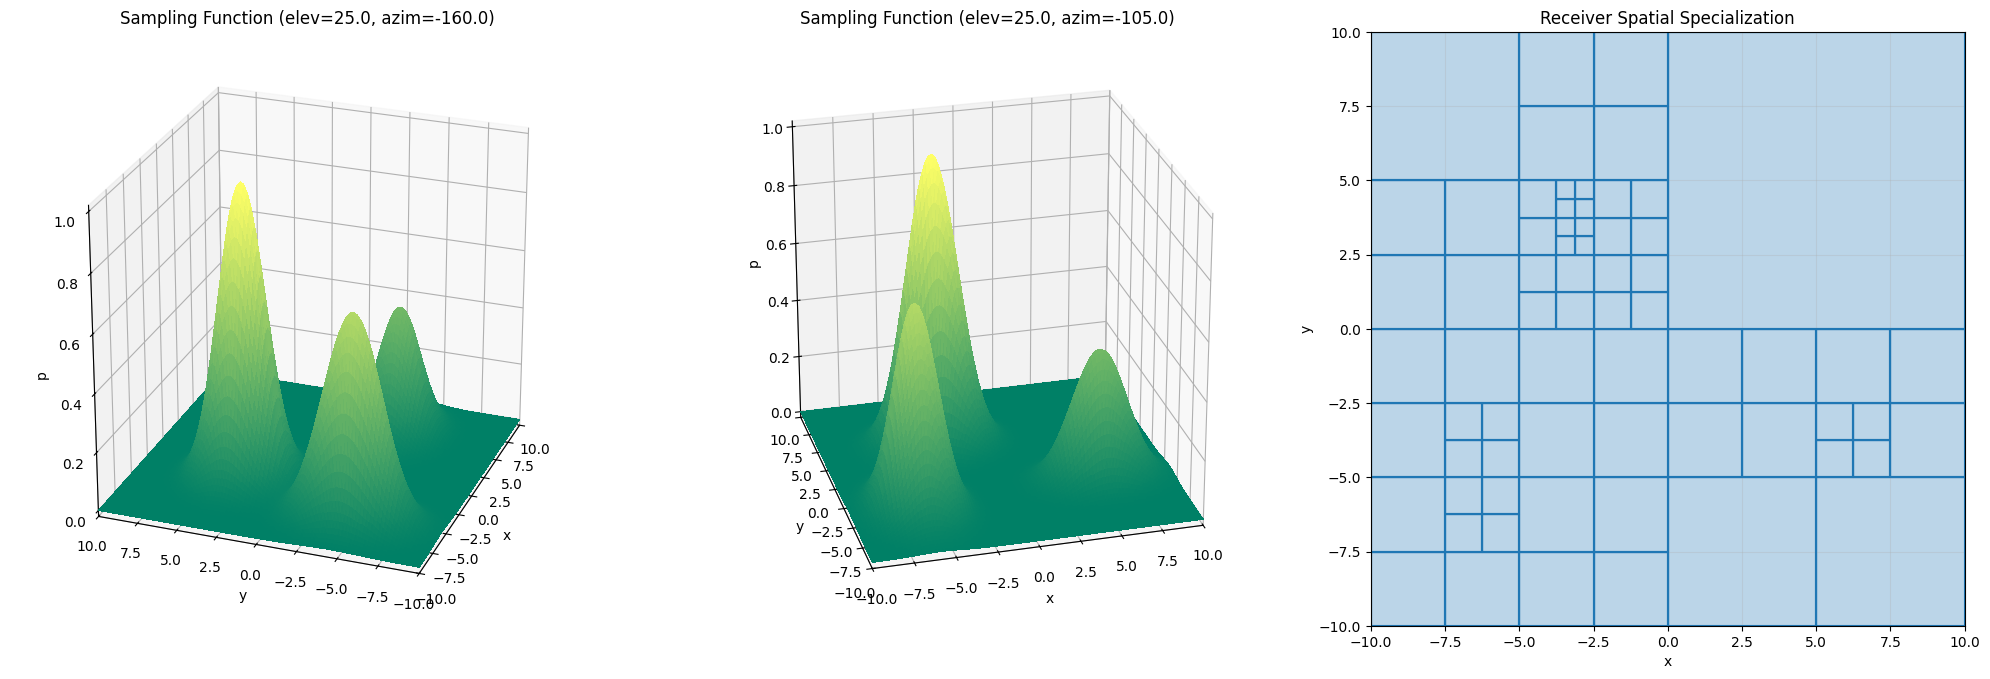

In [12]:
# approximate the sampling function maximum
max_p = get_sampling_function_max(sampling_function)

# initialize the random number generator
rng = random.Random(SEED)

# set the receiver plot steps
plot_steps = (
    {round(idx * (N_STEPS - 1) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    rsample = sample(sampling_function, max_p, rng)
    tsample = receiver.forward(rsample, bias=0.0)
    receiver.backward(rsample, tsample, feedback=0.0)
    # plot the receiver
    if step in plot_steps:
        fig = plt.figure(figsize=(20, 7))
        ax = [
            fig.add_subplot(1, 3, 1, projection="3d"),
            fig.add_subplot(1, 3, 2, projection="3d"),
            fig.add_subplot(1, 3, 3),
        ]
        plot_sampling_function(ax[0], sampling_function, elev=25.0, azim=-160.0)
        plot_sampling_function(ax[1], sampling_function, elev=25.0, azim=-105.0)
        plot_receiver(ax[2], receiver)
        # adjust the aspect ratio of each plot
        for axis in ax[:2]:
            axis.set_box_aspect((1, 1, 1), zoom=0.95)
        fig.tight_layout()
        plt.show()